<a href="https://colab.research.google.com/github/FurqanAlyy/AI-ML-NIAI/blob/main/0_differentiationfunction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Minimum points:
x = -1.0, f(x) = 4.0


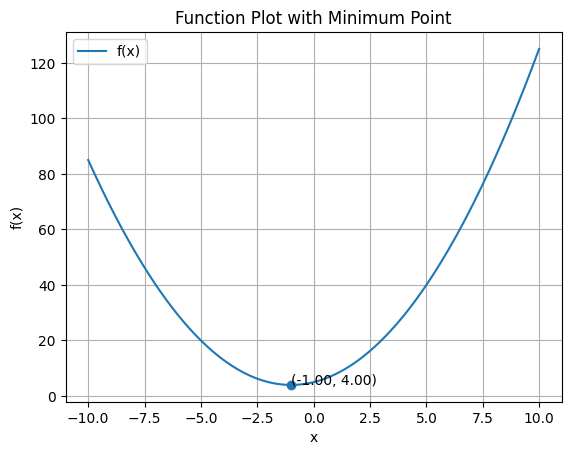

In [3]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def find_minimum_symbolic(func_expr, var):
    # First derivative
    first_derivative = sp.diff(func_expr, var)

    # Solve f'(x) = 0
    critical_points = sp.solve(first_derivative, var)

    minima = []

    for point in critical_points:
        # Second derivative test
        second_derivative = sp.diff(first_derivative, var)
        value = second_derivative.subs(var, point)

        if value > 0:
            func_value = func_expr.subs(var, point)
            minima.append((float(point), float(func_value)))

    return minima


def plot_function(func_expr, var, minima, x_range=(-10, 10)):
    # Convert symbolic function to numerical
    f_lambdified = sp.lambdify(var, func_expr, 'numpy')

    x_vals = np.linspace(x_range[0], x_range[1], 400)
    y_vals = f_lambdified(x_vals)

    plt.figure()
    plt.plot(x_vals, y_vals, label="f(x)")

    # Plot minima points
    for x_min, y_min in minima:
        plt.scatter(x_min, y_min)
        plt.text(x_min, y_min, f"({x_min:.2f}, {y_min:.2f})")

    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Function Plot with Minimum Point")
    plt.legend()
    plt.grid()
    plt.show()


# Example usage
x = sp.symbols('x')
f = x**2 + 2*x + 5

min_points = find_minimum_symbolic(f, x)

print("Minimum points:")
for point, value in min_points:
    print(f"x = {point}, f(x) = {value}")

# Plot the function
plot_function(f, x, min_points)